<a href="https://colab.research.google.com/github/Karthikeya-lol/TIRUPATI_RAINFALL-VS-MUMBAI_RAINFALL/blob/main/Untitled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      IN Tirupati  T.precipitation_sum (mm)  year  month rainfall_category  \
0      1995-01-01                       0.0  1995      1           no rain   
1      1995-01-02                       0.0  1995      1           no rain   
2      1995-01-03                       0.0  1995      1           no rain   
3      1995-01-04                       0.0  1995      1           no rain   
4      1995-01-05                       0.2  1995      1        light rain   
...           ...                       ...   ...    ...               ...   
10953  2024-12-27                      18.2  2024     12     moderate rain   
10954  2024-12-28                       0.0  2024     12           no rain   
10955  2024-12-29                       0.0  2024     12           no rain   
10956  2024-12-30                       1.2  2024     12        light rain   
10957  2024-12-31                       0.0  2024     12           no rain   

       IN Mumbai  M.precipitation_sum (mm)  year  months rainfa

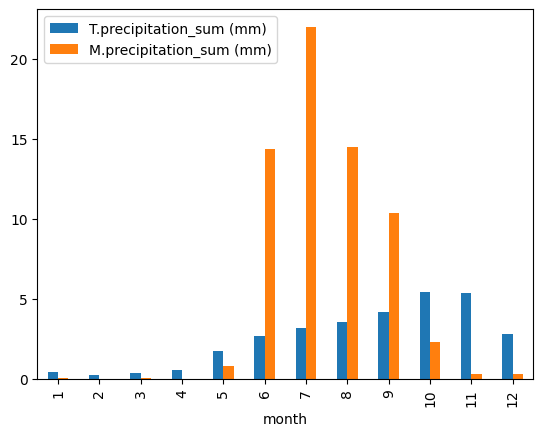

===highest rainfall===


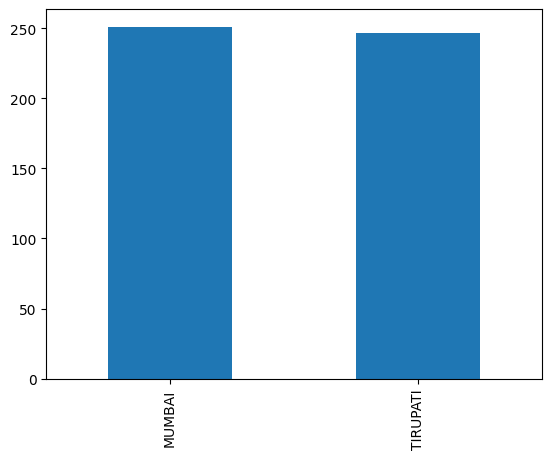

In [42]:
import pandas as pd
import matplotlib.pyplot as pyt
M=pd.read_csv("mumbai_rainfall (1).csv",parse_dates=["time"])
T=pd.read_csv("tirupati_rainfall (1).csv",parse_dates=["time"])
M.rename(columns={"time":"IN Mumbai"},inplace=True)
T.rename(columns={"time":"IN Tirupati"},inplace=True)
M.rename(columns={"precipitation_sum (mm)":"M.precipitation_sum (mm)"}, inplace=True)
T.rename(columns={"precipitation_sum (mm)":"T.precipitation_sum (mm)"}, inplace=True)
M["year"]=M["IN Mumbai"].dt.year
T["year"]=T["IN Tirupati"].dt.year
M["months"]=M["IN Mumbai"].dt.month
T["month"]=T["IN Tirupati"].dt.month
M["rainfall_category"]=M["M.precipitation_sum (mm)"].apply( lambda x: "no rain" if x==0
else "light rain" if x<=10 else "moderate rain" if x<=30 else "heavy rain")
T["rainfall_category"]=T["T.precipitation_sum (mm)"].apply( lambda x: "no rain" if x==0 else "light rain" if x<=10 else "moderate rain" if x<=30 else "heavy rain")
combined=pd.concat([T,M],axis=1)
print(combined)
print("="*40)
print("===MUMBAI==")
print("total rainfall from 1995 to 2024:",M["M.precipitation_sum (mm)"].sum())
print("Average rainfall:",M["M.precipitation_sum (mm)"].mean())
print("Highest rainfall record:",M["M.precipitation_sum (mm)"].max())
print("total rainfall days:",(M["M.precipitation_sum (mm)"]>0).sum())
print("AVERAGE OF RAINFALL monthly wise:",M.groupby("months")["M.precipitation_sum (mm)"].mean())
print("="*40)
print("===TIRUPATI===")
print("total rainfall from 1995 to 2024:",T["T.precipitation_sum (mm)"].sum())
print("Average rainfall:",T["T.precipitation_sum (mm)"].mean())
print("Highest rainfall record:",T["T.precipitation_sum (mm)"].max())
print("total rainfall days:",(T["T.precipitation_sum (mm)"]>0).sum())
print("AVERAGE OF RAINFALL monthly wise:",T.groupby("month")["T.precipitation_sum (mm)"].mean())
Avg=combined.groupby("month")[["T.precipitation_sum (mm)", "M.precipitation_sum (mm)"]].mean()
print("===combined comparision===")
Avg.plot(kind="bar")
pyt.show()
print("===highest rainfall===")
Maxg=pd.Series([M["M.precipitation_sum (mm)"].max(),T["T.precipitation_sum (mm)"].max()],index=["MUMBAI", "TIRUPATI"])
Maxg.plot(kind="bar")
pyt.show()